# Load and Understand the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import pandas as pd
import os

print(os.getcwd())

c:\Users\deepa\Desktop\CVD-XAI\SKIT-AI-2023-2027-14\Trained Models


In [9]:
df = pd.read_excel("../DataSets/Clinical Dataset.xlsx")

In [11]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 70000
Number of columns: 13


In [12]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [13]:
df.tail()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1
69999,99999,20540,1,170,72.0,120,80,2,1,0,0,1,0


# Understand Data Types

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [15]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [17]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [18]:
print("Duplicate IDs:", df["id"].duplicated().sum())

Duplicate IDs: 0


In [19]:
df = df.drop_duplicates()

In [20]:
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (70000, 13)


In [21]:
X = df.drop(columns=["id", "cardio"])
y = df["cardio"]

In [22]:
for column in df.columns:
    print("\n", column)
    print(df[column].unique())


 id
[    0     1     2 ... 99996 99998 99999]

 age
[18393 20228 18857 ... 14925 17727 17926]

 gender
[2 1]

 height
[168 156 165 169 151 157 178 158 164 173 181 172 170 154 162 163 153 159
 166 155 160 175 171 152 187 148 179 180 188 185 167 183 174 176 161 184
 177 182  76 149 142 150 144 147 186 146 141 195 140 198 145 143 196 138
 194 190 134 136 100 120 189 137 192 122 250 191 117  70  97 119 130 110
 193  75 132  71 135  67 125 139 133  74  98 112 207  68  55  81  80  64
  91  60 109  72 197  65 128 105 108 200 104 111 113  96 131  59  66  99
  57]

 weight
[ 62.    85.    64.    82.    56.    67.    93.    95.    71.    68.
  80.    60.    78.   112.    75.    52.    83.    69.    90.    45.
  65.    59.    66.    74.   105.    73.    55.    70.    72.    63.
  50.   107.    84.    77.    79.    76.    58.   115.    97.    53.
  57.    49.   110.    94.    92.    87.   103.    88.    99.   100.
  61.    48.    54.    51.    47.    91.   104.    81.    98.   108.
  89.   101.  

In [23]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


## Target
### cardio
#### 0 → No cardiovascular disease
#### 1 → Cardiovascular disease

In [56]:
print("Target Distribution:")
print(df["cardio"].value_counts())

Target Distribution:
cardio
0    35021
1    34979
Name: count, dtype: int64


In [57]:
print("\nTarget Percentage:")
print(df["cardio"].value_counts(normalize=True) * 100)


Target Percentage:
cardio
0    50.03
1    49.97
Name: proportion, dtype: float64


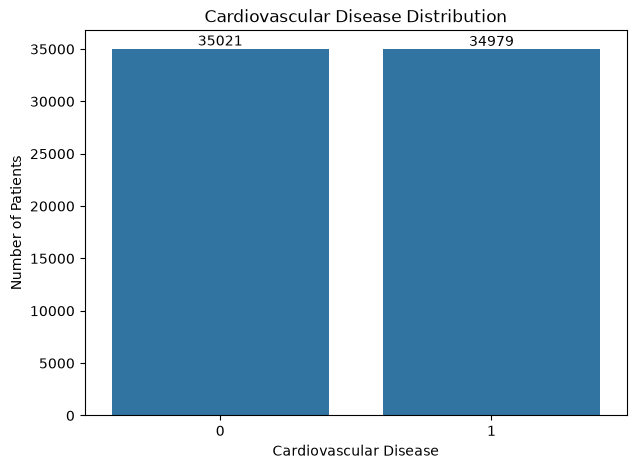

In [58]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(data=df, x="cardio")

plt.title("Cardiovascular Disease Distribution")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

# Analyze Age

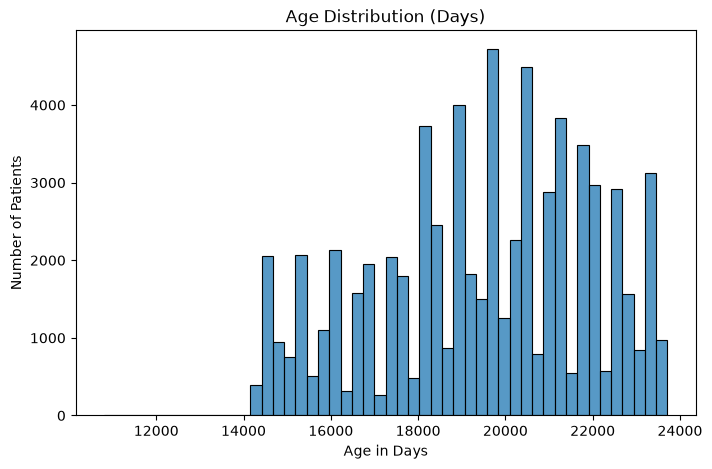

In [27]:
plt.figure(figsize=(8, 5))

sns.histplot(df["age"], bins=50)

plt.title("Age Distribution (Days)")
plt.xlabel("Age in Days")
plt.ylabel("Number of Patients")

plt.show()

# Analyze Height and Weight

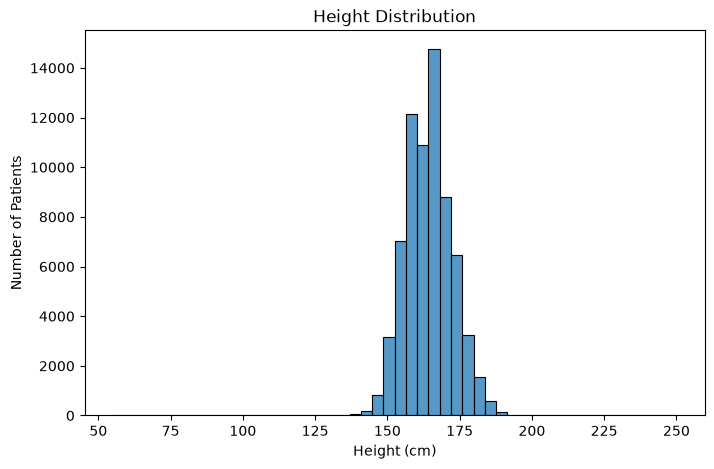

In [28]:
plt.figure(figsize=(8, 5))

sns.histplot(df["height"], bins=50)

plt.title("Height Distribution")
plt.xlabel("Height (cm)")
plt.ylabel("Number of Patients")

plt.show()

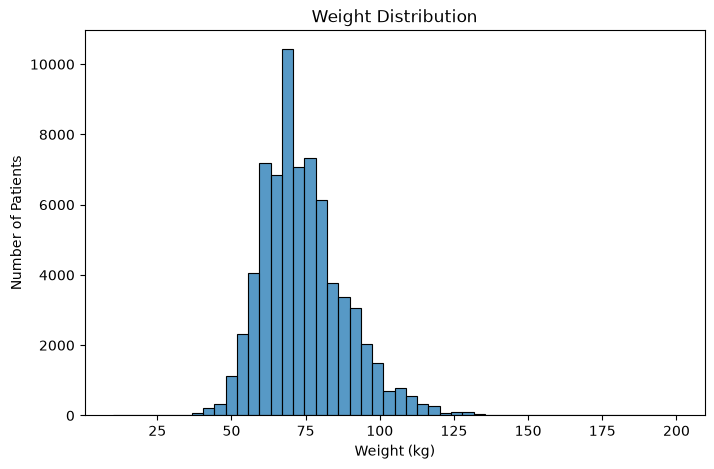

In [29]:
plt.figure(figsize=(8, 5))

sns.histplot(df["weight"], bins=50)

plt.title("Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Number of Patients")

plt.show()

# Analyze Blood Pressure

### ap_hi → Systolic BP
### ap_lo → Diastolic BP

In [30]:
df[["ap_hi", "ap_lo"]].describe()

,ap_hi,ap_lo
count,70000.000000,70000.000000
mean,128.817286,96.630414
std,154.011419,188.472530
min,-150.000000,-70.000000
25%,120.000000,80.000000
50%,120.000000,80.000000
75%,140.000000,90.000000
max,16020.000000,11000.000000


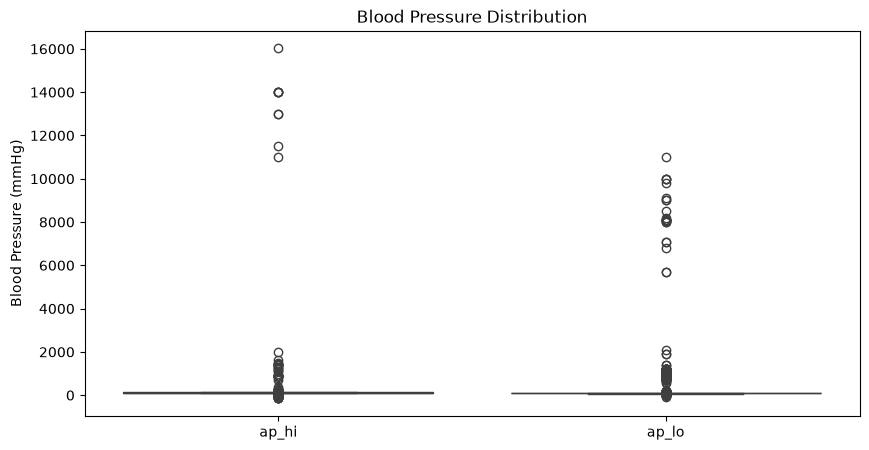

In [31]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df[["ap_hi", "ap_lo"]])

plt.title("Blood Pressure Distribution")
plt.ylabel("Blood Pressure (mmHg)")

plt.show()

# Analyze Cholesterol
#### 1 → Normal
#### 2 → Above Normal
#### 3 → Well Above Normal

In [32]:
print(df["cholesterol"].value_counts())

cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64


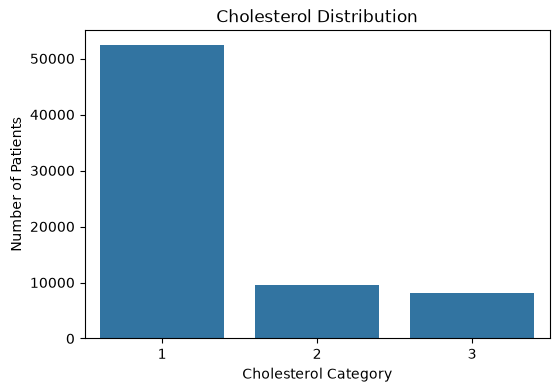

In [33]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="cholesterol")

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol Category")
plt.ylabel("Number of Patients")

plt.show()

# Analyze Glucose

In [34]:
print(df["gluc"].value_counts())

gluc
1    59479
3     5331
2     5190
Name: count, dtype: int64


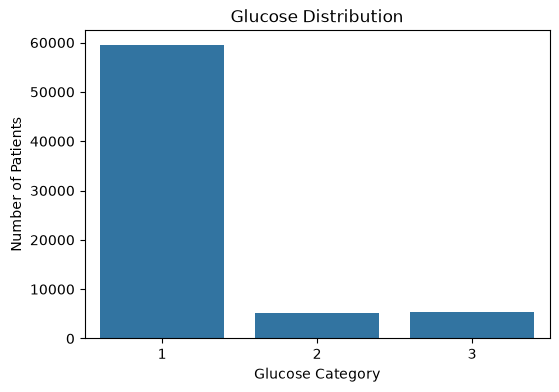

In [35]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="gluc")

plt.title("Glucose Distribution")
plt.xlabel("Glucose Category")
plt.ylabel("Number of Patients")

plt.show()

# Analyze Lifestyle Features

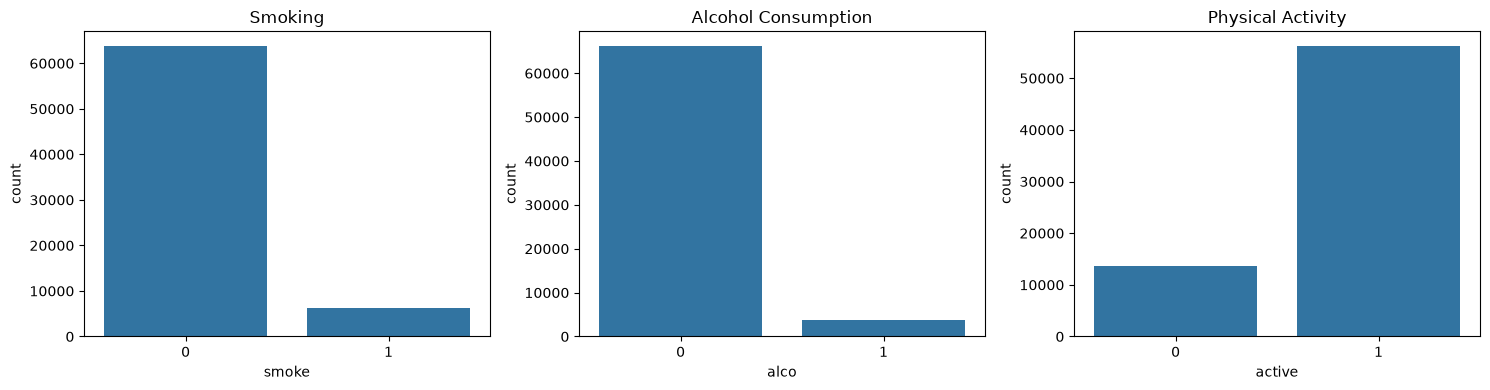

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x="smoke", ax=axes[0])
axes[0].set_title("Smoking")

sns.countplot(data=df, x="alco", ax=axes[1])
axes[1].set_title("Alcohol Consumption")

sns.countplot(data=df, x="active", ax=axes[2])
axes[2].set_title("Physical Activity")

plt.tight_layout()
plt.show()

# Correlation Analysis

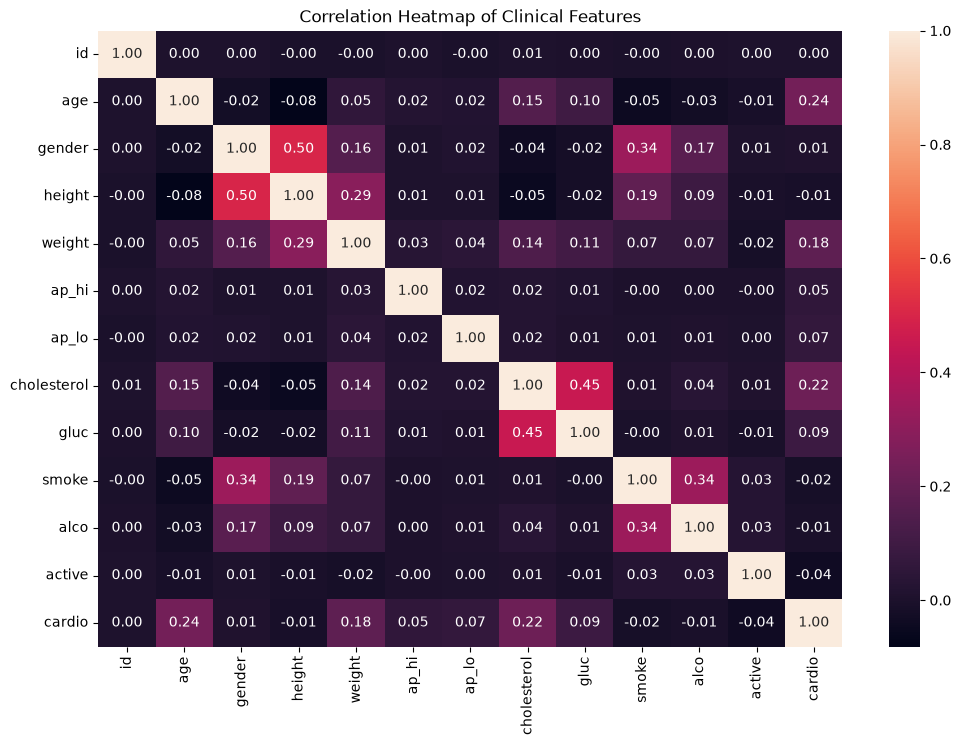

In [37]:
plt.figure(figsize=(12, 8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Clinical Features")

plt.show()

# Feature vs Target Analysis

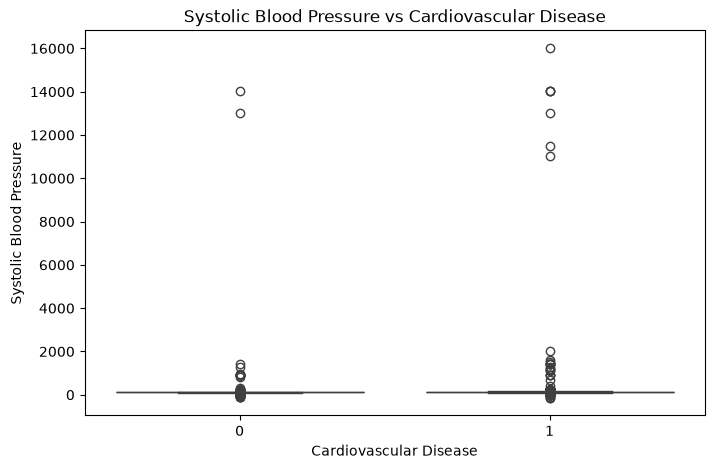

In [38]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="cardio",
    y="ap_hi"
)

plt.title("Systolic Blood Pressure vs Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Systolic Blood Pressure")

plt.show()

<Axes: xlabel='cardio', ylabel='weight'>

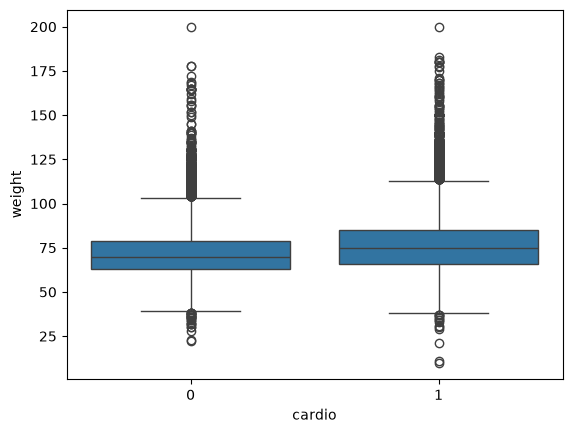

In [39]:
sns.boxplot(data=df, x="cardio", y="weight")

<Axes: xlabel='cardio', ylabel='height'>

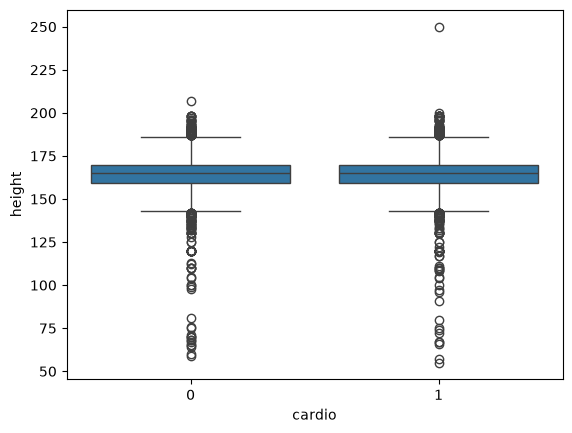

In [40]:
sns.boxplot(data=df, x="cardio", y="height")

# Categorical Feature vs CVD

In [41]:
pd.crosstab(
    df["cholesterol"],
    df["cardio"],
    normalize="index"
) * 100

cardio,0,1
cholesterol,,
1,55.989310,44.010690
2,39.784271,60.215729
3,23.456484,76.543516


In [42]:
pd.crosstab(
    df["smoke"],
    df["cardio"],
    normalize="index"
) * 100

cardio,0,1
smoke,,
0,49.789287,50.210713
1,52.520668,47.479332


In [43]:
pd.crosstab(
    df["active"],
    df["cardio"],
    normalize="index"
) * 100


cardio,0,1
active,,
0,46.422593,53.577407
1,50.910933,49.089067


# Outlier Analysis

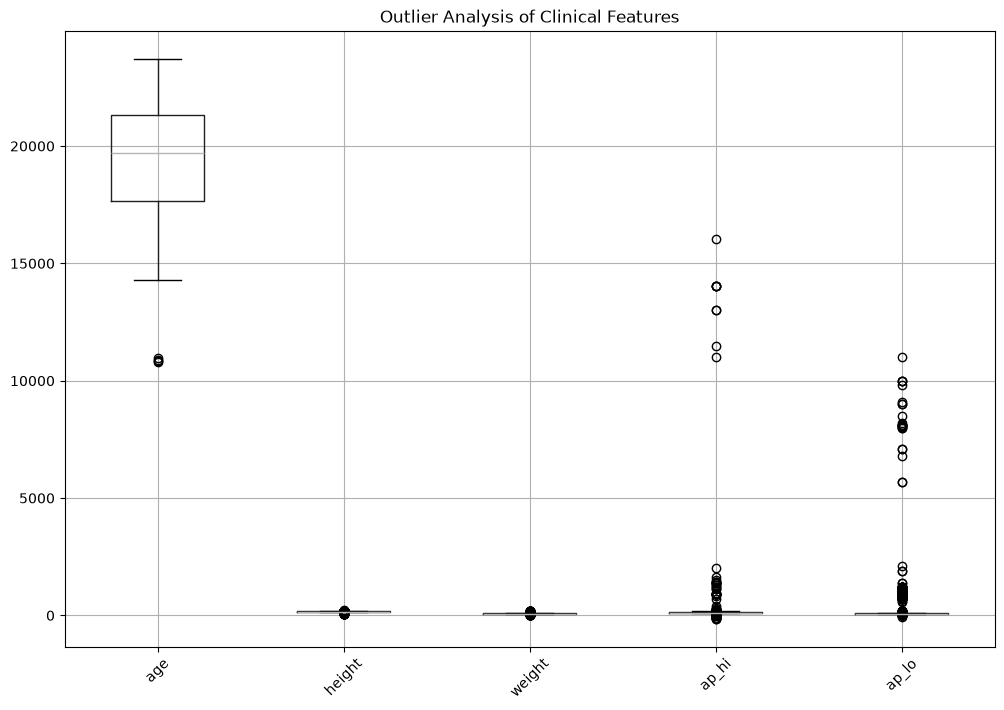

In [44]:
numerical_columns = [
    "age",
    "height",
    "weight",
    "ap_hi",
    "ap_lo"
]

plt.figure(figsize=(12, 8))

df[numerical_columns].boxplot()

plt.xticks(rotation=45)
plt.title("Outlier Analysis of Clinical Features")

plt.show()

# Feature Engineering

In [47]:
#Age in years
df["age_years"] = df["age"] / 365.25

In [48]:
df["age_years"].describe()

count    70000.000000
mean        53.302850
std          6.754967
min         29.563313
25%         48.361396
50%         53.943874
75%         58.390144
max         64.922656
Name: age_years, dtype: float64

In [49]:
# BMI
df["BMI"] = df["weight"] / ((df["height"] / 100) ** 2)

In [50]:
df["BMI"].describe()

count    70000.000000
mean        27.556513
std          6.091511
min          3.471784
25%         23.875115
50%         26.374068
75%         30.222222
max        298.666667
Name: BMI, dtype: float64

In [51]:
# Pulse Pressure
df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]

In [52]:
# Mean Arterial Pressure
df["MAP"] = (df["ap_hi"] + 2 * df["ap_lo"]) / 3

# Target Distribution

In [61]:
print("Target Distribution:")
print(df["cardio"].value_counts())

print("\nTarget Percentage:")
print(df["cardio"].value_counts(normalize=True) * 100)

Target Distribution:
cardio
0    35021
1    34979
Name: count, dtype: int64

Target Percentage:
cardio
0    50.03
1    49.97
Name: proportion, dtype: float64


# Numerical Statistics

In [62]:
numerical_features = [
    "age",
    "height",
    "weight",
    "ap_hi",
    "ap_lo"
]

df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,70000.0,19468.865814,2467.251667,10798.0,17664.0,19703.0,21327.0,23713.0
height,70000.0,164.359229,8.210126,55.0,159.0,165.0,170.0,250.0
weight,70000.0,74.205690,14.395757,10.0,65.0,72.0,82.0,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.0,120.0,140.0,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.0,80.0,90.0,11000.0


# Numerical Distributions

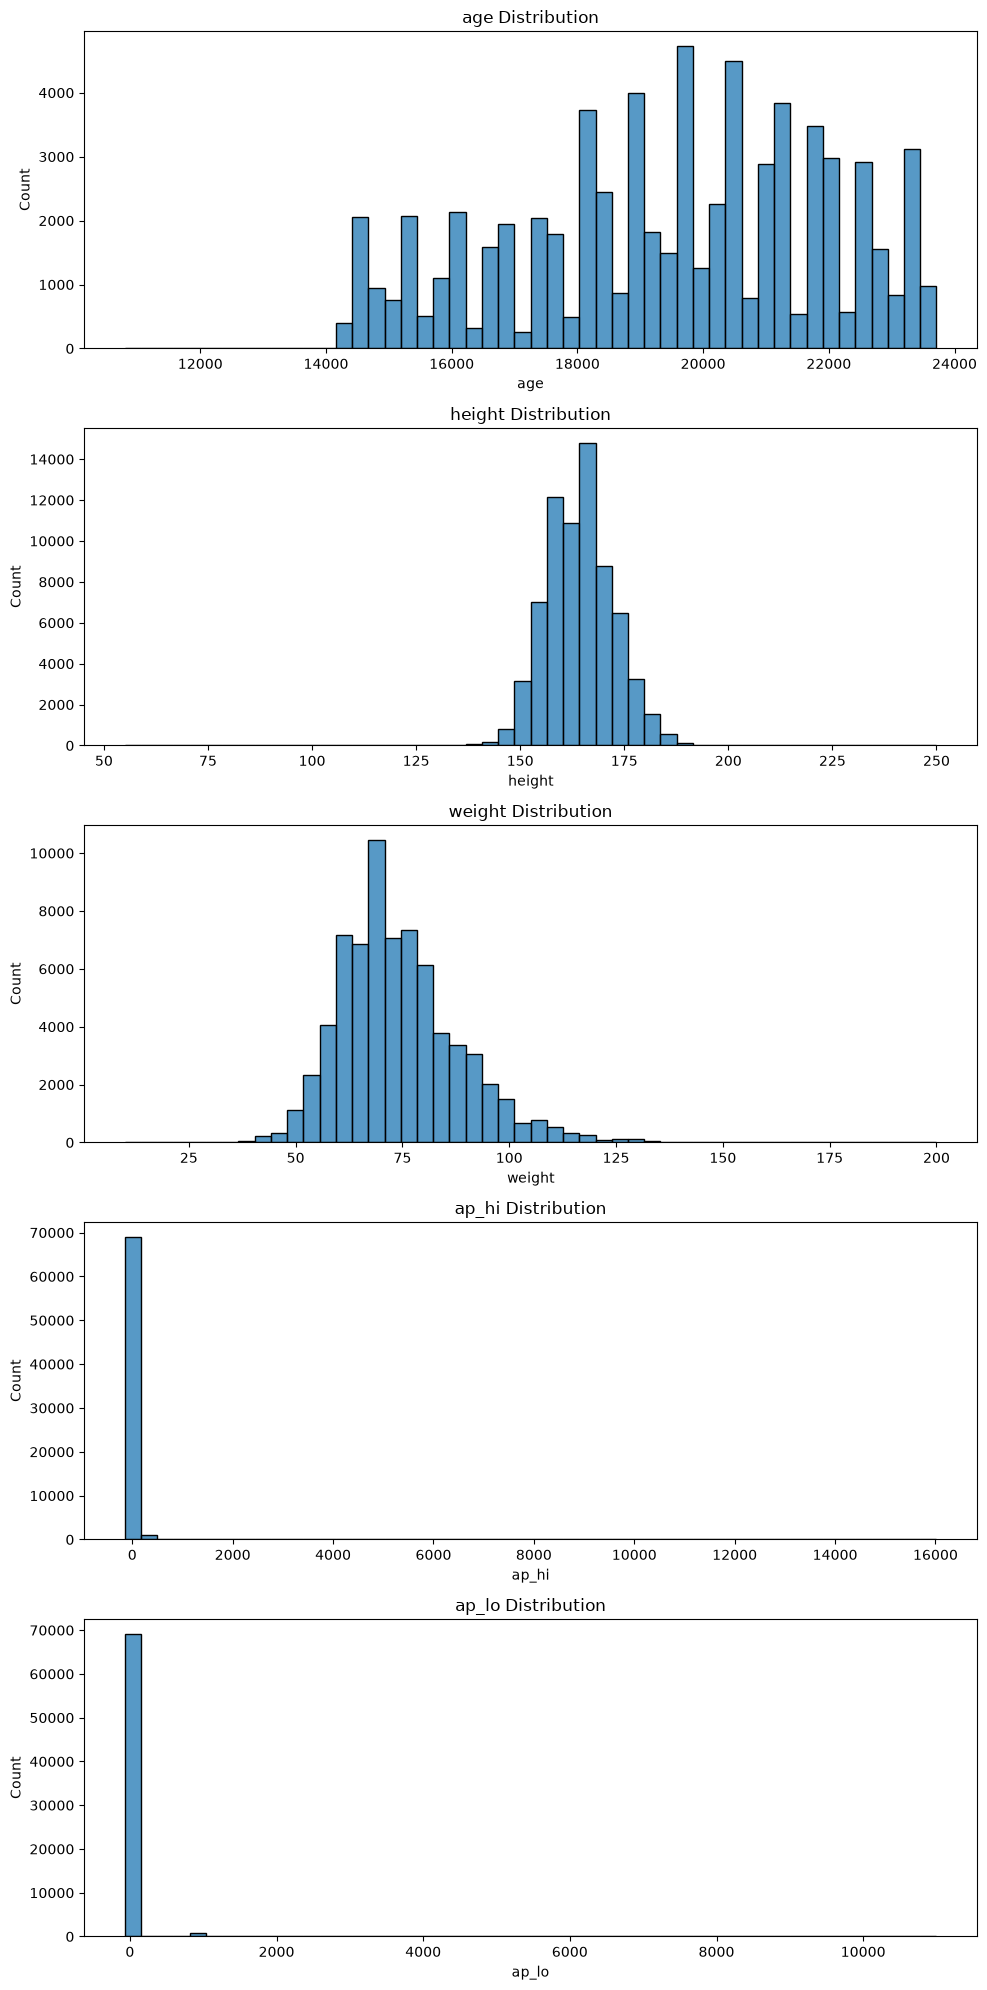

In [63]:
fig, axes = plt.subplots(5, 1, figsize=(10, 20))

for ax, feature in zip(axes, numerical_features):
    sns.histplot(df[feature], bins=50, ax=ax)
    ax.set_title(f"{feature} Distribution")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

# Invalid BP

In [64]:
print("Systolic BP <= 0:",
      (df["ap_hi"] <= 0).sum())

print("Diastolic BP <= 0:",
      (df["ap_lo"] <= 0).sum())

Systolic BP <= 0: 7
Diastolic BP <= 0: 22


# Extremely High BP

In [65]:
print("Systolic BP > 250:")
display(
    df[df["ap_hi"] > 250][
        ["id", "age", "gender", "ap_hi", "ap_lo", "cardio"]
    ].head(20)
)

print("Diastolic BP > 150:")
display(
    df[df["ap_lo"] > 150][
        ["id", "age", "gender", "ap_hi", "ap_lo", "cardio"]
    ].head(20)
)

Systolic BP > 250:


,id,age,gender,ap_hi,ap_lo,cardio
1876,2654,15116,1,902,60,0
2014,2845,22712,2,906,0,0
4817,6822,14425,1,909,60,0
7763,11089,21032,1,11500,90,1
8915,12710,18870,1,1420,80,1
9557,13616,22659,1,701,110,1
13895,19827,15996,1,1500,80,1
17713,25314,22398,2,907,70,1
23867,34120,16131,1,906,0,1
25464,36339,15835,2,14020,80,1


Diastolic BP > 150:


,id,age,gender,ap_hi,ap_lo,cardio
228,314,17489,2,160,1100,1
241,334,21932,2,160,1000,1
260,357,18217,1,140,800,1
329,458,23407,1,160,1000,1
345,482,18704,1,140,1000,1
473,680,15226,1,150,1033,1
559,805,20430,2,200,1000,1
613,886,18963,1,140,1000,1
649,928,18190,1,190,1100,1
653,932,21842,1,180,1000,1


# Systolic vs Diastolic

In [66]:
invalid_bp_order = df[df["ap_hi"] <= df["ap_lo"]]

print(
    "Records where systolic BP <= diastolic BP:",
    len(invalid_bp_order)
)

display(
    invalid_bp_order[
        ["id", "ap_hi", "ap_lo", "cardio"]
    ].head(20)
)

Records where systolic BP <= diastolic BP: 1236


,id,ap_hi,ap_lo,cardio
228,314,160,1100,1
241,334,160,1000,1
260,357,140,800,1
329,458,160,1000,1
345,482,140,1000,1
473,680,150,1033,1
474,681,120,150,0
559,805,200,1000,1
567,815,14,90,1
613,886,140,1000,1


# Height and Weight Validation

In [67]:
print("Height < 100 cm:")
print((df["height"] < 100).sum())

print("\nHeight > 220 cm:")
print((df["height"] > 220).sum())

print("\nWeight < 30 kg:")
print((df["weight"] < 30).sum())

print("\nWeight > 200 kg:")
print((df["weight"] > 200).sum())

Height < 100 cm:
29

Height > 220 cm:
1

Weight < 30 kg:
7

Weight > 200 kg:
0


In [68]:
print("Suspicious height records:")
display(
    df[(df["height"] < 100) | (df["height"] > 220)]
    [["id", "age", "gender", "height", "weight", "cardio"]]
    .head(20)
)

print("Suspicious weight records:")
display(
    df[(df["weight"] < 30) | (df["weight"] > 200)]
    [["id", "age", "gender", "height", "weight", "cardio"]]
    .head(20)
)

Suspicious height records:


,id,age,gender,height,weight,cardio
224,309,21800,2,76,55.0,0
6486,9223,21220,1,250,86.0,1
7598,10843,14661,2,70,72.0,0
8171,11662,17646,2,97,170.0,1
12770,18218,19594,1,75,168.0,1
13265,18928,22456,2,71,68.0,0
14323,20459,22005,1,67,57.0,1
15167,21686,15812,1,70,68.0,0
16699,23859,19680,2,74,98.0,1
17277,24690,17530,1,98,45.0,0


Suspicious weight records:


,id,age,gender,height,weight,cardio
26806,38312,23284,1,157,23.0,0
29488,42156,20408,2,177,22.0,0
33817,48318,21582,2,178,11.0,1
34276,48976,14664,2,128,28.0,0
57858,82567,18804,2,165,10.0,1
60188,85931,21855,1,162,21.0,1
60699,86650,18875,1,171,29.0,1


# Check the BP Problem More Carefully

In [69]:
print("Negative systolic:", (df["ap_hi"] <= 0).sum())
print("Negative diastolic:", (df["ap_lo"] <= 0).sum())

print("Systolic > 300:", (df["ap_hi"] > 300).sum())
print("Diastolic > 200:", (df["ap_lo"] > 200).sum())

print("Systolic <= Diastolic:",
      (df["ap_hi"] <= df["ap_lo"]).sum())

Negative systolic: 7
Negative diastolic: 22
Systolic > 300: 40
Diastolic > 200: 953
Systolic <= Diastolic: 1236


In [70]:
print("Systolic BP values above 300:")
display(
    df[df["ap_hi"] > 300]
    [["id", "ap_hi", "ap_lo", "cardio"]]
    .head(30)
)

print("\nDiastolic BP values above 200:")
display(
    df[df["ap_lo"] > 200]
    [["id", "ap_hi", "ap_lo", "cardio"]]
    .head(30)
)

Systolic BP values above 300:


,id,ap_hi,ap_lo,cardio
1876,2654,902,60,0
2014,2845,906,0,0
4817,6822,909,60,0
7763,11089,11500,90,1
8915,12710,1420,80,1
9557,13616,701,110,1
13895,19827,1500,80,1
17713,25314,907,70,1
23867,34120,906,0,1
25464,36339,14020,80,1



Diastolic BP values above 200:


,id,ap_hi,ap_lo,cardio
228,314,160,1100,1
241,334,160,1000,1
260,357,140,800,1
329,458,160,1000,1
345,482,140,1000,1
473,680,150,1033,1
559,805,200,1000,1
613,886,140,1000,1
649,928,190,1100,1
653,932,180,1000,1


# Create a Data Quality Summary

In [71]:
quality_summary = pd.DataFrame({
    "Issue": [
        "Missing values",
        "Duplicate rows",
        "Duplicate IDs",
        "Negative systolic BP",
        "Negative diastolic BP",
        "Systolic BP > 300",
        "Diastolic BP > 200",
        "Systolic <= Diastolic"
    ],
    "Count": [
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df["id"].duplicated().sum(),
        (df["ap_hi"] <= 0).sum(),
        (df["ap_lo"] <= 0).sum(),
        (df["ap_hi"] > 300).sum(),
        (df["ap_lo"] > 200).sum(),
        (df["ap_hi"] <= df["ap_lo"]).sum()
    ]
})

display(quality_summary)

,Issue,Count
0,Missing values,0
1,Duplicate rows,0
2,Duplicate IDs,0
3,Negative systolic BP,7
4,Negative diastolic BP,22
5,Systolic BP > 300,40
6,Diastolic BP > 200,953
7,Systolic <= Diastolic,1236
